In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil

In [4]:
TRAIN_SET_PATH = 'train.csv'
train_df = pd.read_csv(TRAIN_SET_PATH, index_col=0)

In [5]:
train_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
id,,,,,,,,,,,,
0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [6]:
train_df.rename(columns={'cb_person_default_on_file': 'cb_defaulter_on_file'}, inplace=True)

In [7]:
train_df.shape

(58645, 12)

In [8]:
train_df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_defaulter_on_file          0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58645 entries, 0 to 58644
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  58645 non-null  int64  
 1   person_income               58645 non-null  int64  
 2   person_home_ownership       58645 non-null  object 
 3   person_emp_length           58645 non-null  float64
 4   loan_intent                 58645 non-null  object 
 5   loan_grade                  58645 non-null  object 
 6   loan_amnt                   58645 non-null  int64  
 7   loan_int_rate               58645 non-null  float64
 8   loan_percent_income         58645 non-null  float64
 9   cb_defaulter_on_file        58645 non-null  object 
 10  cb_person_cred_hist_length  58645 non-null  int64  
 11  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 5.8+ MB


In [10]:
train_df.person_home_ownership.value_counts()

person_home_ownership
RENT        30594
MORTGAGE    24824
OWN          3138
OTHER          89
Name: count, dtype: int64

In [11]:
train_df.cb_defaulter_on_file.value_counts()

cb_defaulter_on_file
N    49943
Y     8702
Name: count, dtype: int64

In [12]:
pd.set_option('future.no_silent_downcasting', True)
defaulter_map = {'N': 0, 'Y': 1}
train_df.cb_defaulter_on_file = train_df.cb_defaulter_on_file.replace(to_replace=defaulter_map)

In [13]:
onehot_cols = ['person_home_ownership', 'loan_intent']
ordinal_cols = ['loan_grade']

In [14]:
onehot_df = train_df[onehot_cols]
ord_df = train_df[ordinal_cols]

In [15]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
ord_enc = OrdinalEncoder()
onehot_enc = OneHotEncoder(sparse_output=False)

In [16]:
ord_encoded_cols = ord_enc.fit_transform(ord_df)

In [17]:
onehot_encoded_cols = onehot_enc.fit_transform(onehot_df)

In [18]:
onehot_col_names = onehot_enc.get_feature_names_out(onehot_cols)

In [19]:
train_df.loan_grade = ord_encoded_cols

In [20]:
train_df.drop(onehot_cols, axis=1, inplace=True)

In [21]:
train_df = train_df.join(pd.DataFrame(onehot_encoded_cols, columns = onehot_col_names))

In [22]:
train_df.drop(['person_age'], axis=1, inplace=True)

In [23]:
corr_matrix = train_df.corr(numeric_only=True)

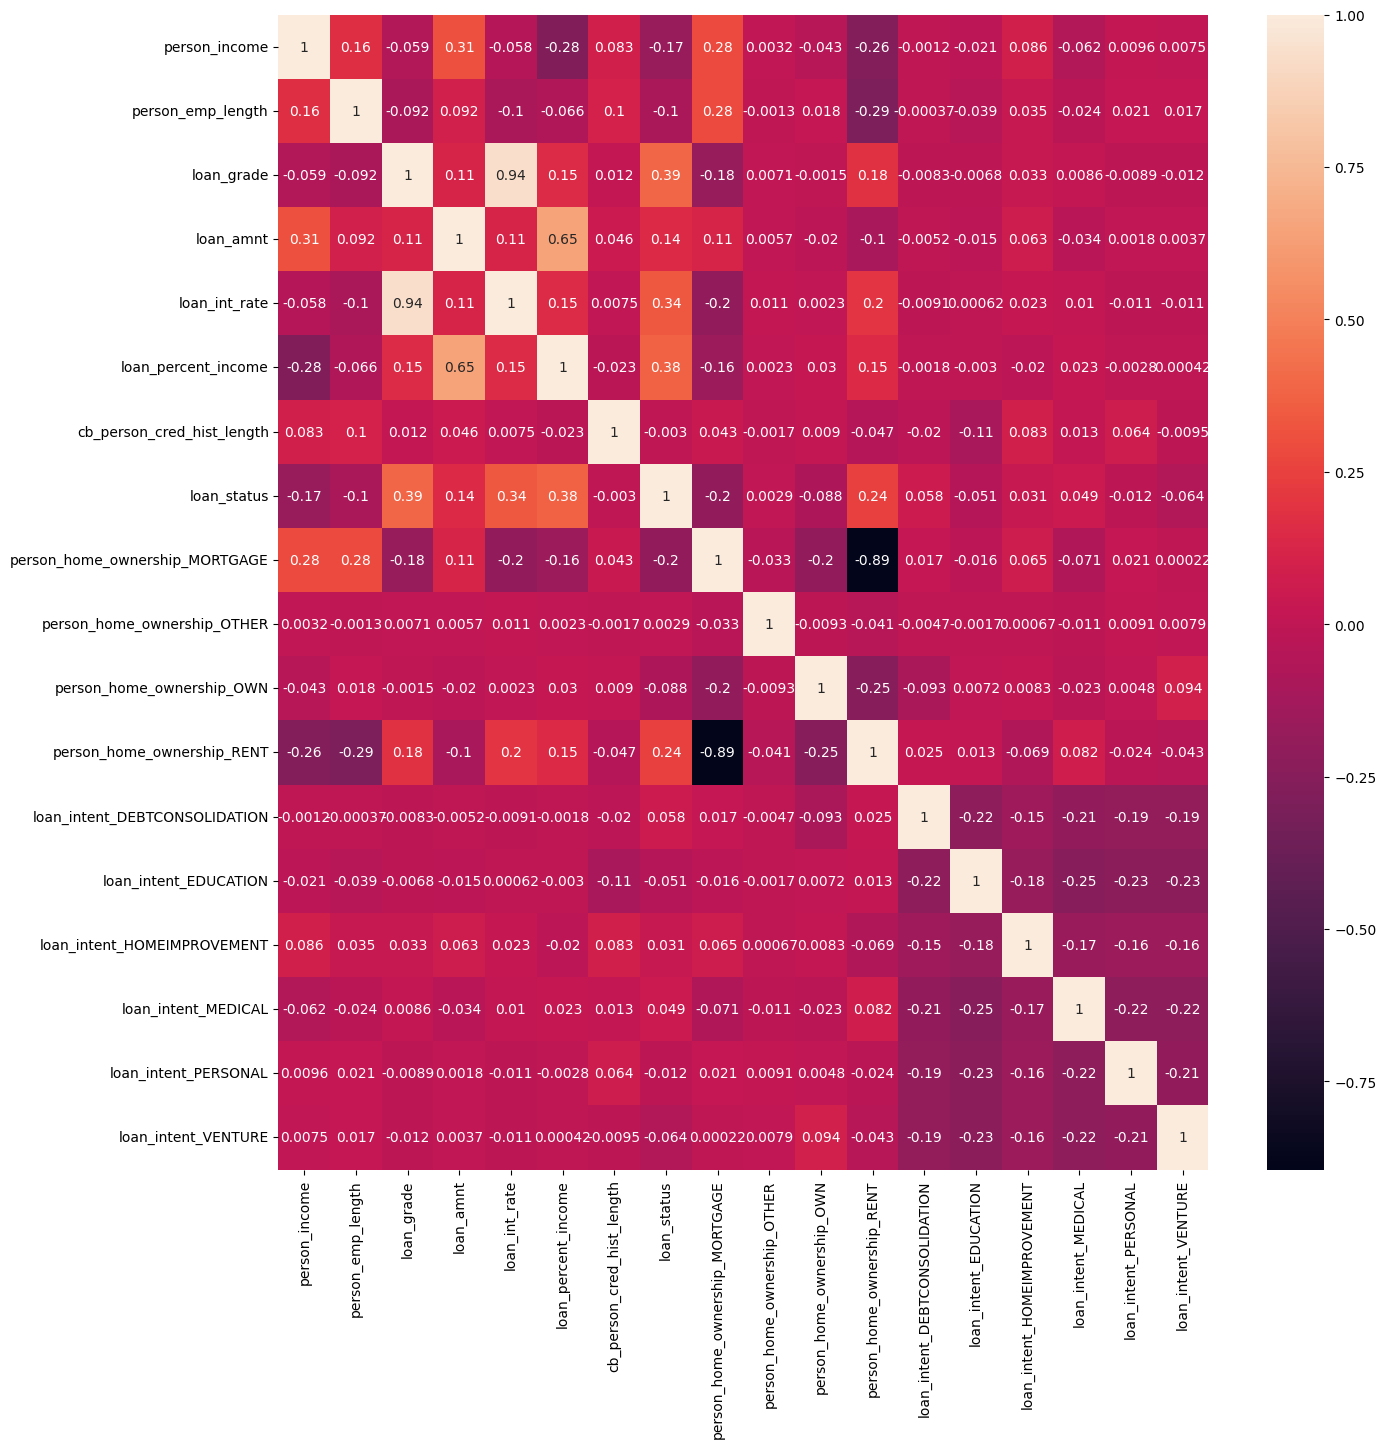

In [24]:
plt.figure(figsize=(15,15))
sns.heatmap(corr_matrix, annot=True)
plt.show()

<Figure size 1000x1000 with 0 Axes>

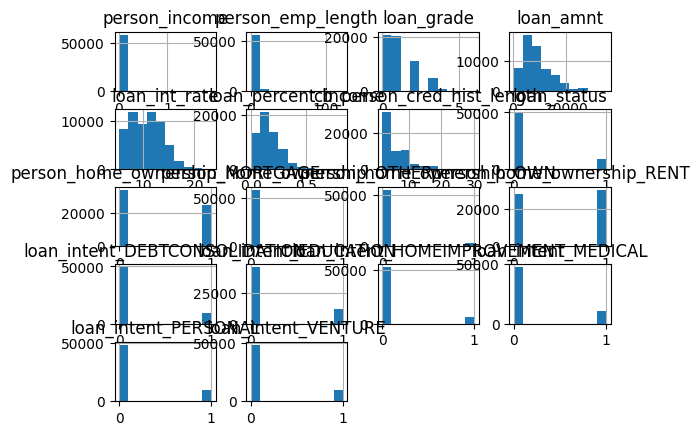

In [25]:
plt.figure(figsize=(10,10))
train_df.hist()
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
X = train_df.drop('loan_status', axis=1)
Y = train_df.loan_status

In [27]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

In [28]:
from sklearn.preprocessing import RobustScaler
rob_sclr = RobustScaler()

In [29]:
x_train_sd = rob_sclr.fit_transform(x_train)
x_test_sd = rob_sclr.transform(x_test)

In [30]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

In [31]:
rfc = RandomForestClassifier(random_state=42)
hgbc = HistGradientBoostingClassifier(random_state=42)

In [32]:
rfc.fit(x_train_sd, y_train)
hgbc.fit(x_train_sd, y_train)

HistGradientBoostingClassifier(random_state=42)

In [33]:
y_pred_rfc = rfc.predict(x_test_sd)
y_pred_hgbc = hgbc.predict(x_test_sd)

In [35]:
from sklearn.metrics import accuracy_score

In [36]:
print(f'RandomForestClassifier accuracy: {round(accuracy_score(y_test, y_pred_rfc)*100, 3)} %')

RandomForestClassifier accuracy: 95.205 %


In [37]:
print(f'HistGradientBoostingRegressor accuracy: {round(accuracy_score(y_test, y_pred_hgbc)*100, 3)} %')

HistGradientBoostingRegressor accuracy: 95.219 %


In [40]:
from sklearn.metrics import confusion_matrix, classification_report

In [41]:
cm_rfc = confusion_matrix(y_test, y_pred_rfc)
cm_hgbc = confusion_matrix(y_test, y_pred_hgbc)

In [42]:
cr_hgbc = classification_report(y_test, y_pred_hgbc)
cr_rfc = classification_report(y_test, y_pred_rfc)

In [52]:
print(f'Confusin Matrix HGBC: \n{cm_hgbc}\n')
print(f'Confusin Matrix RFC: \n{cm_rfc}')

Confusin Matrix HGBC: 
[[12483   130]
 [  571  1478]]

Confusin Matrix RFC: 
[[12492   121]
 [  582  1467]]


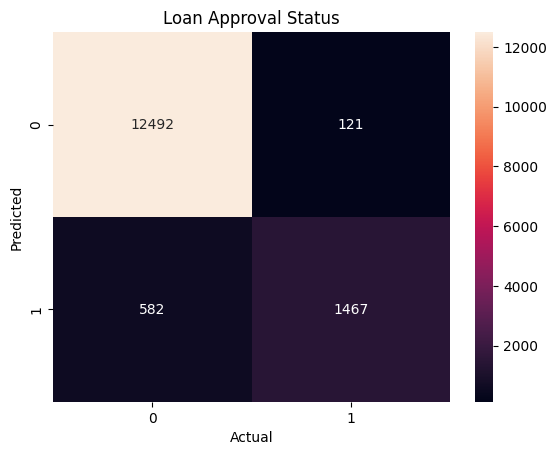

In [50]:
sns.heatmap(cm_rfc, annot=True, fmt='d')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Loan Approval Status')
plt.show()

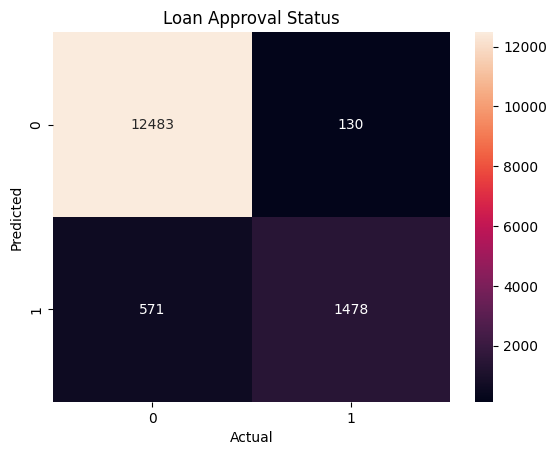

In [51]:
sns.heatmap(cm_hgbc, annot=True, fmt='d')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Loan Approval Status')
plt.show()